# Unidad 4 — Notebook 1: Árboles de Decisión

**Materia:** Métodos de Análisis de Datos 1 (MAD1)  
**Departamento de Matemática — Universidad Nacional del Sur (UNS)**  
**Nombre: Godoy Martín**  

---

## Glosario de siglas

| Sigla | Significado |
|-------|-------------|
| CART | Classification and Regression Trees (Árboles de Clasificación y Regresión) |
| CV | Cross-Validation (Validación Cruzada) |
| ML | Machine Learning (Aprendizaje Automático) |
| AP | Aprendizaje Supervisado |

---

## Objetivos

- Calcular manualmente los criterios de impureza **Gini** y **Entropía** para evaluar splits.
- Implementar y ajustar árboles de decisión usando `scikit-learn`.
- Analizar el efecto de la profundidad máxima sobre el sobreajuste.

---

## Parte 1 — Cálculo a mano: Gini y Entropía

Considerá el siguiente dataset de 8 pacientes. La variable respuesta es `Enfermedad` (Sí/No). Queremos evaluar si conviene hacer el split en la variable `Glucosa > 120`.

| Paciente | Glucosa | Enfermedad |
|----------|---------|------------|
| 1        | 95      | No         |
| 2        | 110     | No         |
| 3        | 130     | Sí         |
| 4        | 145     | Sí         |
| 5        | 105     | No         |
| 6        | 160     | Sí         |
| 7        | 115     | No         |
| 8        | 140     | Sí         |

El split propuesto divide en:
- **Nodo izquierdo** (Glucosa ≤ 120): pacientes 1, 2, 5, 7
- **Nodo derecho** (Glucosa > 120): pacientes 3, 4, 6, 8

### 1.1 Impureza de Gini

Recordá que para un nodo con clases $k = 1, \ldots, K$:

$$\text{Gini}(t) = 1 - \sum_{k=1}^{K} p_k^2$$

donde $p_k$ es la proporción de observaciones de clase $k$ en el nodo $t$.

La impureza ponderada del split es:

$$\text{Gini}_{\text{split}} = \frac{n_L}{n} \cdot \text{Gini}(t_L) + \frac{n_R}{n} \cdot \text{Gini}(t_R)$$

**Ejercicio 1.1.a** — Calculá la impureza de Gini para el nodo raíz (antes del split, los 8 pacientes juntos).

*Espacio para desarrollo:*

La impureza Gini para el nodo raíz, antes del split es:$$ Gini(raíz) = 1 - p_\text{si}^2 - p_\text{no}^2 $$ mirando la tabla antes de ser separados, hay 4 pacientes enfermos y 4 no enfermos de entre 8 pacientes, entonces: $$p_\text{si} = \frac{4}{8} = \frac{1}{2} \quad \text{y} \quad p_\text{no} = \frac{1}{2}$$ se sigue que:

$$Gini(raíz) = 1 - (\frac{1}{2})^2 - (\frac{1}{2})^2 = 1 - \frac{2}{4} = \frac{1}{2} = 0.5$$

**Ejercicio 1.1.b** — Calculá Gini para el nodo izquierdo y para el nodo derecho por separado.

- Lado izquierdo: $$Gini(t_L) = 1 - p_\text{si}^2 - p_\text{no}^2$$ en este caso son 4 no enfermos y 0 enfermos de entre 4 personas, entonces: $$p_\text{si} = \frac{0}{4} \quad \text{y} \quad p_\text{no}= \frac{4}{4} = 1 \implies Gini(t_L) = 1 - (0)^2 - (1)^2 = 0$$
- Lado derecho: $$Gini(t_R) = 1 - p_\text{si}^2 - p_\text{no}^2$$ en el caso del nodo derecho son 4 enfermos y 0 no enfermos entre 4 personas, por tanto: $$p_\text{si} = \frac{4}{4} = 1 \quad \text{y} \quad p_\text{no} = \frac{0}{4} \implies Gini(t_R) = 1 - (1)^2 - (0)^2 = 0 $$

**Ejercicio 1.1.c** — Calculá la impureza ponderada del split. ¿Hubo ganancia respecto al nodo raíz?

La impureza en este caso se calcula como $$Gini_\text{split} = \frac{n_L}{n} \cdot Gini(t_L) + \frac{n_R}{n} \cdot Gini(t_R)$$ siendo n = 8, nL = nR = 4 y ambos $$Gini(t_L) = Gini(t_R) = 0$$ por tanto: $$Gini_\text{split} = \frac{n_L}{n} \cdot 0 + \frac{n_R}{n} \cdot 0 = 0$$

La ganancia de Informacion de un split se calcula con: $$Ganancia = Gini(raíz) - Gini_\text{split}$$ en este caso: $$Ganancia = 0.5 - 0 = 0.5$$ eso significa que hubo una ganancia de 0.5 con respecto al nodo raíz.

### 1.2 Entropía e Información Ganada

La impureza por **Entropía** de Shannon para un nodo $t$ es:

$$H(t) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

La **Ganancia de Información** (Information Gain) del split es:

$$IG = H(\text{raíz}) - \left( \frac{n_L}{n} \cdot H(t_L) + \frac{n_R}{n} \cdot H(t_R) \right)$$

> **Convención:** si $p_k = 0$, el término $0 \cdot \log_2(0) = 0$.

**Ejercicio 1.2.a** — Calculá la Entropía del nodo raíz, del nodo izquierdo y del nodo derecho.

- Entropía del nodo raíz: En nuestro caso es: $$H(\text{raíz}) = - p_\text{si} \log_2(p_\text{si}) - p_\text{no} \log_2(p_\text{no})$$ entonces $$H(\text{raíz}) = - \frac{1}{2} \log_2(\frac{1}{2}) - \frac{1}{2} \log_2(\frac{1}{2})$$
resulta que $$H(\text{raíz}) = \frac{1}{2} + \frac{1}{2} = 1 $$
- Entropía del nodo izq: $$H(t_L) = - p_\text{si} \log_2(p_\text{si}) - p_\text{no} \log_2(p_\text{no})$$
esto es $$H(t_L) = - 0 \log_2(0) - 1 \log_2(1) = - 0 - 0 = 0$$
- Entropía del nodo der: $$H(t_R) = - p_\text{si} \log_2(p_\text{si}) - p_\text{no} \log_2(p_\text{no})$$
queda: $$H(t_R) = - 1 \log_2(1) - 0 \log_2(0) = -0 - 0 = 0 $$

**Ejercicio 1.2.b** — Calculá la Ganancia de Información del split.

Por la formula de ganancia de información tenemos que: $$ IG = H(\text{raíz}) - \left( \frac{n_L}{n} \cdot H(t_L) + \frac{n_R}{n} \cdot H(t_R) \right)$$
en nuestro caso $$ IG = 1 - \left( \frac{n_L}{n} \cdot 0 + \frac{n_R}{n} \cdot 0 \right) = 1 - 0 = 1 $$

**Ejercicio 1.2.c** — ¿Ambos criterios (Gini y Entropía) concuerdan en que este split es bueno? ¿Qué diferencias conceptuales tienen?

Si, ambos criterios coinciden en que el split es bueno. El indice Gini disminuye de 0.5 a 0 mientras que la Entropía disminuye de 1 a 0, obteniendo asi la máxima ganancia de Informacion.
Tanto el indice Gini como la Entropía son medidas de la impureza utilizadas para decidir como dividir los nodos en un árbol de decision. Ambos alcanzan el valor 0 cuando el nodo es completamente puro y van aumentando a medida que las clases están mezcladas, pero, difieren en la forma en que cuantifican esa impureza: Gini mide la impureza como la probabilidad de equivocarse si clasificamos al azar según las proporciones del nodo, mientras que la Entropía mide la incertidumbre o cantidad de Informacion presente en el nodo.

---

## Parte 2 — Verificación computacional

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

# Dataset del ejercicio a mano
glucosa = np.array([95, 110, 130, 145, 105, 160, 115, 140])
enfermedad = np.array([0, 0, 1, 1, 0, 1, 0, 1])  # 0=No, 1=Sí
X_manual = glucosa.reshape(-1, 1)
y_manual = enfermedad

**Ejercicio 2.1** — Completá el código para entrenar un árbol con criterio Gini y otro con Entropía, ambos con profundidad máxima 1 (un solo split).

In [3]:
# Árbol con criterio Gini
arbol_gini = DecisionTreeClassifier(
    criterion="gini",        # TU CÓDIGO ACÁ
    max_depth=1,        # TU CÓDIGO ACÁ
    random_state=42
)
arbol_gini.fit(X_manual, y_manual)  # TU CÓDIGO ACÁ

# Árbol con criterio Entropía
arbol_entropia = DecisionTreeClassifier(
    criterion="entropy",        # TU CÓDIGO ACÁ
    max_depth=1,        # TU CÓDIGO ACÁ
    random_state=42
)
arbol_entropia.fit(X_manual, y_manual)  # TU CÓDIGO ACÁ

print("Árbol Gini:")
print(export_text(arbol_gini, feature_names=['Glucosa']))
print("\nÁrbol Entropía:")
print(export_text(arbol_entropia, feature_names=['Glucosa']))

Árbol Gini:
|--- Glucosa <= 122.50
|   |--- class: 0
|--- Glucosa >  122.50
|   |--- class: 1


Árbol Entropía:
|--- Glucosa <= 122.50
|   |--- class: 0
|--- Glucosa >  122.50
|   |--- class: 1



**Ejercicio 2.2** — ¿El umbral de split encontrado por scikit-learn coincide con el que usaste a mano? ¿Por qué puede diferir?

El umbral escogido por el scikit-learn no coincide con el usado a mano, este ultimo fue de 120, sin embargo el scikit-learn utilizo 122.5, puede diferir pues, si nos damos cuenta, todos los valores de glucosa que son <= 115 entran dentro de la clase de "No enfermedad" mientras que los valores de glucosa >=130 entran dentro de la clase "Enfermedad" y el punto medio entre los valores 115 y 130 es justamente 122.5 por tanto es otro valor valido a escoger para separar perfectamente ambas clases.

---

## Parte 3 — Efecto de la profundidad: sobreajuste

Ahora trabajamos con el dataset `make_classification` de scikit-learn para explorar cómo la profundidad del árbol afecta el rendimiento.

In [4]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=300, n_features=5, n_informative=3,
    n_redundant=1, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

**Ejercicio 3.1** — Completá el loop para entrenar árboles con profundidades de 1 a 15 y registrar el accuracy (proporción de predicciones correctas) en train y test.

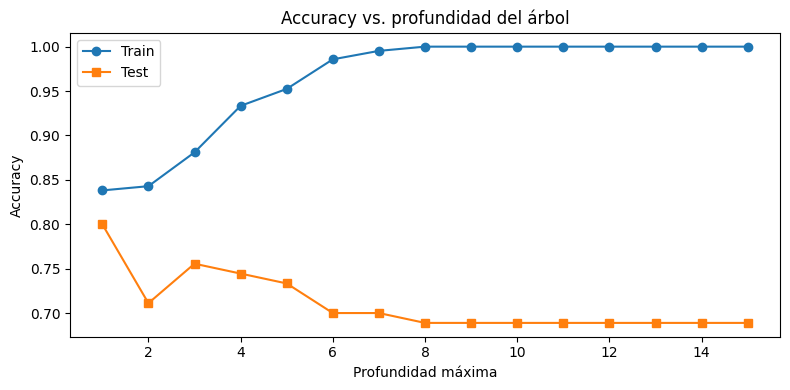

In [6]:
profundidades = range(1, 16)
acc_train = []
acc_test  = []

for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth= d , random_state=42)  # TU CÓDIGO ACÁ
    arbol.fit(X_train, y_train)                                              # TU CÓDIGO ACÁ
    acc_train.append(accuracy_score(y_train, arbol.predict(X_train)))        # TU CÓDIGO ACÁ
    acc_test.append(accuracy_score(y_test, arbol.predict(X_test)))         # TU CÓDIGO ACÁ

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(profundidades, acc_train, marker='o', label='Train')
ax.plot(profundidades, acc_test,  marker='s', label='Test')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs. profundidad del árbol')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 3.2** — Mirá la curva. ¿A partir de qué profundidad el modelo empieza a sobreajustar? ¿Cómo lo identificás en el gráfico?

El modelo empieza a mostrar signos de sobreajuste a una profundidad aproximada de 3-4 (a pesar de que en profundidad 1 aprox tenga su máximo valor la curva test y empieza a caer parece mas bien una pequeña oscilación) pues, a partir de esta el accuracy sobre el conjunto de entrenamiento sigue subiendo, mientras que simultáneamente, el accuracy del conjunto de testeo disminuye. Esto indica que el árbol aprende detalles específicos del conjunto entrenamiento y pierde capacidad de generalizar datos nuevos

**Ejercicio 3.3** — Usá validación cruzada (CV) de 5 folds estratificada para elegir la mejor profundidad. Completá el código.

In [8]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # TU CÓDIGO ACÁ
cv_scores = []

for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth=d, random_state=42)  # TU CÓDIGO ACÁ
    scores = cross_val_score(arbol, X_train, y_train, cv=cv)         # TU CÓDIGO ACÁ
    cv_scores.append(scores.mean())

mejor_d = list(profundidades)[np.argmax(cv_scores)]
print(f'Mejor profundidad por CV: {mejor_d}')
print(f'Accuracy CV promedio: {max(cv_scores):.3f}')

Mejor profundidad por CV: 6
Accuracy CV promedio: 0.838


**Ejercicio 3.4** — Visualizá el árbol final con la profundidad elegida.

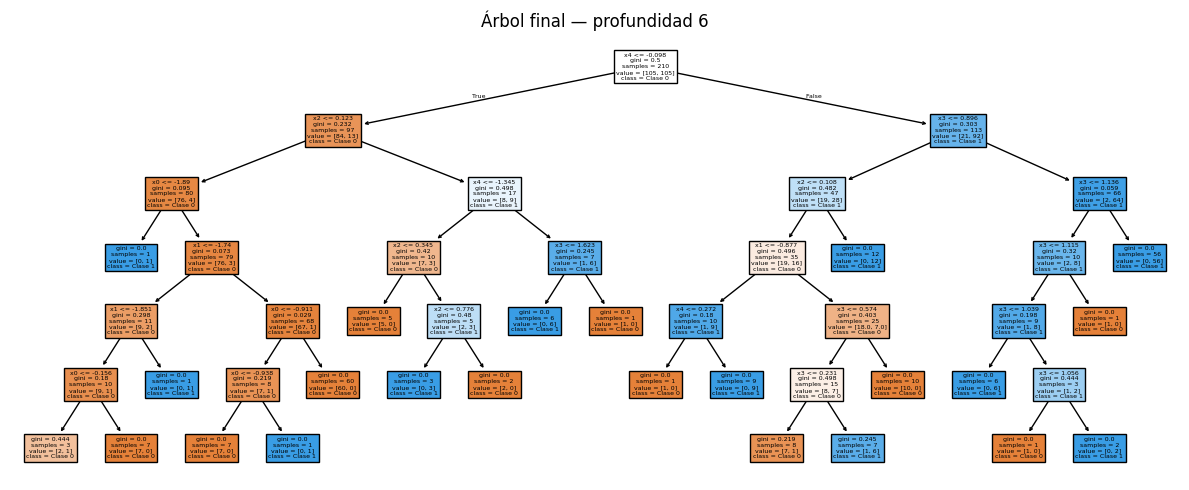

In [9]:
arbol_final = DecisionTreeClassifier(max_depth=mejor_d, random_state=42)
arbol_final.fit(X_train, y_train)  # TU CÓDIGO ACÁ

fig, ax = plt.subplots(figsize=(12, 5))
plot_tree(
    arbol_final,                            # TU CÓDIGO ACÁ
    filled=True,
    feature_names=[f'x{i}' for i in range(X.shape[1])],
    class_names=['Clase 0', 'Clase 1'],
    ax=ax
)
ax.set_title(f'Árbol final — profundidad {mejor_d}')
plt.tight_layout()
plt.show()

---

## Preguntas de reflexión final

1. ¿Qué ventaja tiene la Entropía sobre Gini como criterio de split? ¿Y qué desventaja?
2. Un árbol sin restricción de profundidad sobre el conjunto de entrenamiento tiene accuracy = 1.0. ¿Es un modelo bueno? Justificá.
3. ¿Por qué se usa CV estratificada en lugar de CV simple cuando las clases están desbalanceadas?

1) Una ventaja que tiene la Entropía sobre Gini como criterio de split, es que esta posee una sensibilidad mayor a pequeñas mejoras de pureza en los nodos, es decir, la entropía penaliza a los nodos muy mezclados y recompensa mas a los nodos que quedan muy puros y tiene una ventaja mas conceptual, y esta es que proviene de una teoría de la información, por tanto la ganancia de información tiene un significado muy claro, y este es "¿Cuánta incertidumbre eliminó este split?" lo cual resulta muy util para un análisis teórico. Y sus desventajas son mas bien practicas frente a Gini, dado que este ultimo no hace uso de logaritmos haciendo que Entropía sea mas lento de calcular y produciendo resultados similares con su "competencia".
2) No necesariamente implica que el árbol sea bueno. Que un árbol de decision obtenga accuracy de 1.0 sobre el conjunto de entrenamiento significa que clasifica perfectamente los datos con los que este fue entrenado. Sin embargo, esto puede ser causado por sobreajuste (overfitting) esto es causado por el árbol aprender no solo los patrones generales, sino también particularidades especificas del conjunto de entrenamiento. Por consecuente, puede tener un desempeño mucho peor con datos aun no vistos, derivando en que el modelo resulte no ser bueno.
3) En un caso donde las clases estén desbalanceadas la validación cruzada simple podría generar folds con proporciones muy diferentes entre sí, estro traería como consecuencia que algún fold contenga muy pocos o incluso ningunos ejemplares de la clase minoritaria, produciendo una evaluación poco representativa e inestable del modelo. En cambio, la validación cruzada estratificada, se encarga de que los folds con aproximadamente la misma proporción de clases que había en el conjunto original, permitiendo que haya una evaluación mas justa y confiable del rendimiento del modelo.